In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
two_blobs = pd.read_csv('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/26_DBSCAN/Data/cluster_two_blobs.csv')
two_blobs.head()

,X1,X2
0,0.046733,1.765120
1,-8.994134,-6.508186
2,0.650539,1.264533
3,-9.501554,-6.736493
4,0.057050,0.188215


<Axes: xlabel='X1', ylabel='X2'>

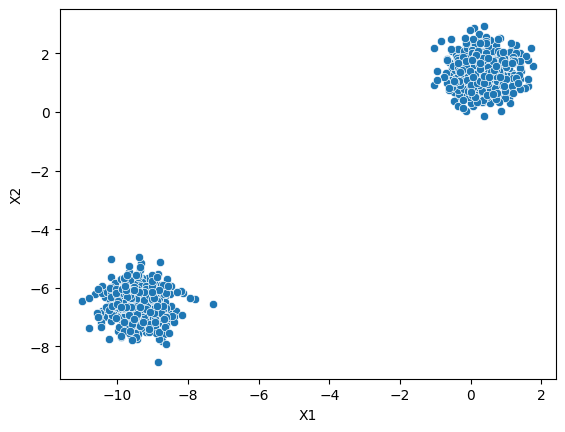

In [3]:
sns.scatterplot(data=two_blobs, x='X1',y='X2')

In [6]:
two_blobs.shape

(1000, 2)

In [4]:
two_blobs_outliers = pd.read_csv('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/26_DBSCAN/Data/cluster_two_blobs_outliers.csv')
two_blobs_outliers.head()

,X1,X2
0,0.046733,1.765120
1,-8.994134,-6.508186
2,0.650539,1.264533
3,-9.501554,-6.736493
4,0.057050,0.188215


<Axes: xlabel='X1', ylabel='X2'>

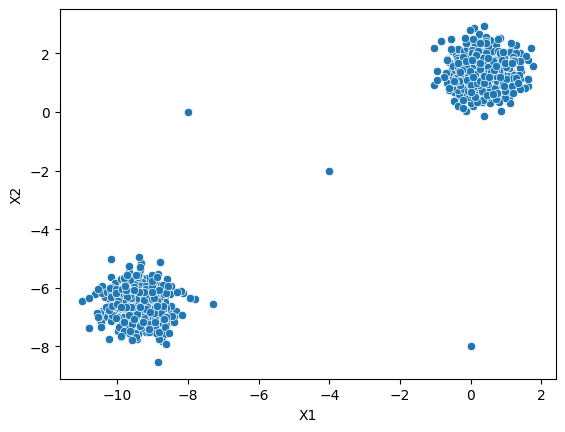

In [5]:
sns.scatterplot(data=two_blobs_outliers, x='X1',y='X2')

In [7]:
two_blobs_outliers.shape

(1003, 2)

In [8]:
def display_categories(model,data):
  labels = model.fit_predict(data)
  sns.scatterplot(data=data,x='X1',y='X2',hue=labels,palette='Set1')

In [9]:
from sklearn.cluster import DBSCAN

In [10]:
dbscan = DBSCAN()

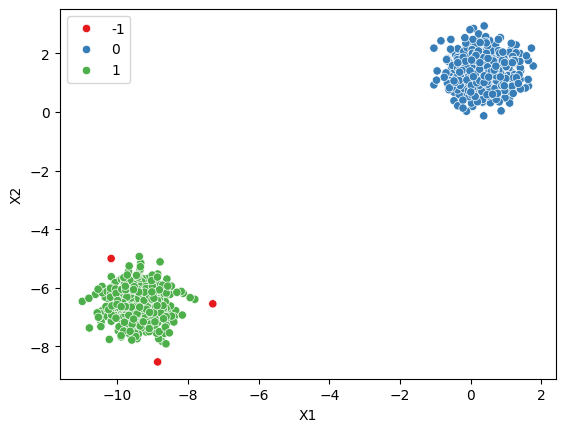

In [11]:
display_categories(dbscan,two_blobs)

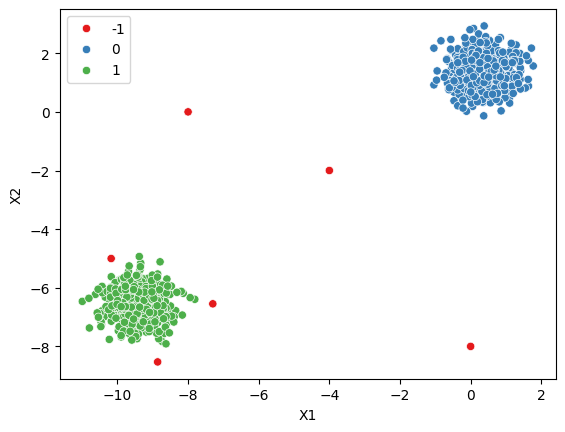

In [12]:
display_categories(dbscan,two_blobs_outliers)

# Epsilon

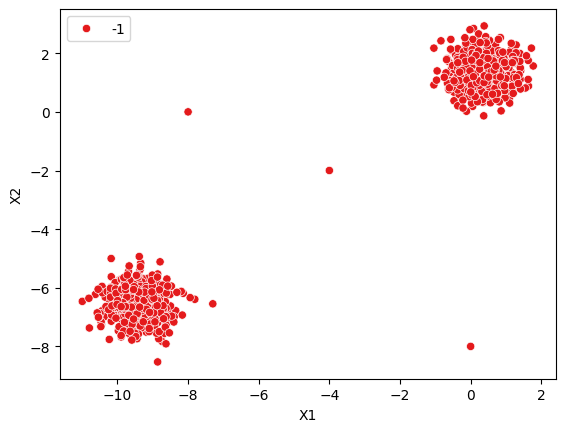

In [13]:
dbscan = DBSCAN(eps=0.0001)
display_categories(dbscan,two_blobs_outliers)

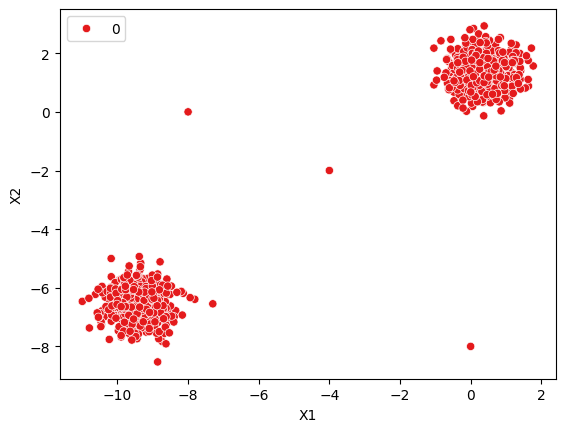

In [14]:
dbscan = DBSCAN(eps=100)
display_categories(dbscan,two_blobs_outliers)

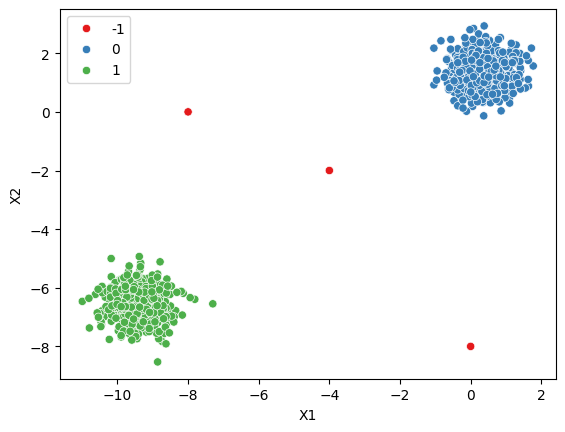

In [15]:
dbscan = DBSCAN(eps=1)
display_categories(dbscan,two_blobs_outliers)

In [16]:
dbscan.labels_

array([ 0,  1,  0, ..., -1, -1, -1])

In [18]:
np.sum(dbscan.labels_ == -1)

np.int64(3)

In [20]:
100*np.sum(dbscan.labels_ == -1)/len(dbscan.labels_)

np.float64(0.29910269192422734)

# Charting reasonable Epsilon Values

In [23]:
outlier_percent = []
number_of_outlier = []


for eps in np.linspace(0.001,10,100):

  dbscan = DBSCAN(eps = eps)
  dbscan.fit(two_blobs_outliers)

  number_of_outlier.append(np.sum(dbscan.labels_==-1))

  outlier_percent.append(100*np.sum(dbscan.labels_ == -1)/len(dbscan.labels_))

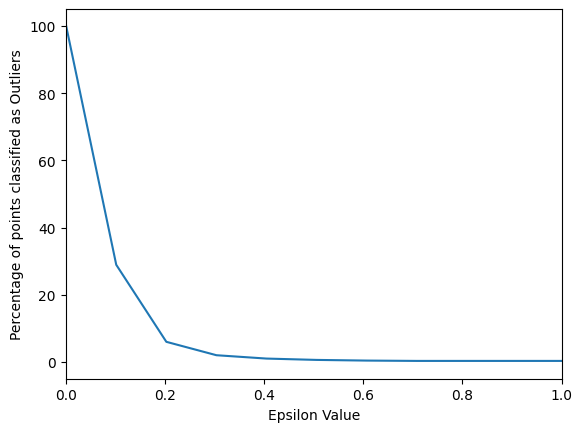

In [30]:
sns.lineplot(x=np.linspace(.001,10,100),y=outlier_percent)
plt.ylabel("Percentage of points classified as Outliers")
plt.xlabel("Epsilon Value")
plt.xlim(0,1)
#plt.ylim(0,20)
plt.show()

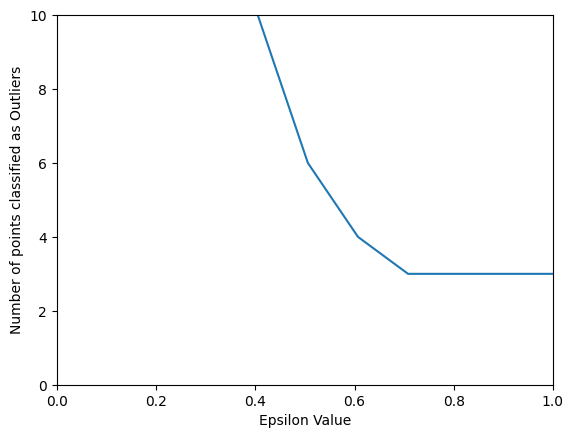

In [33]:
sns.lineplot(x=np.linspace(.001,10,100),y=number_of_outlier)
plt.ylabel("Number of points classified as Outliers")
plt.xlabel("Epsilon Value")
plt.xlim(0,1)
plt.ylim(0,10)
plt.show()

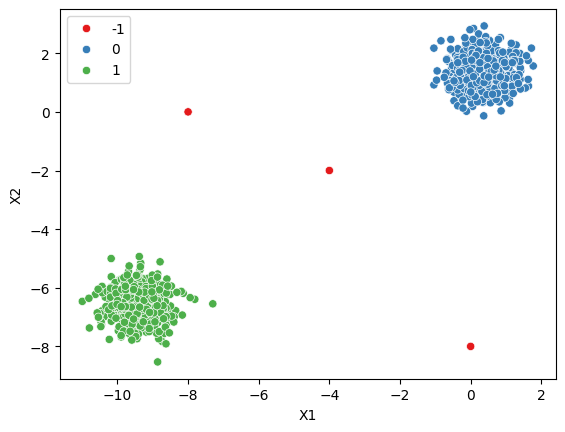

In [36]:
dbscan = DBSCAN(eps=0.7)
display_categories(dbscan,two_blobs_outliers)

# Minimum Number of Samples

In [38]:
#help(DBSCAN)

In [39]:
outlier_percent = []

for n in np.arange(1,100):

  dbscan = DBSCAN(min_samples=n)
  dbscan.fit(two_blobs_outliers)

  outlier_percent.append(100*np.sum(dbscan.labels_==-1)/len(dbscan.labels_))

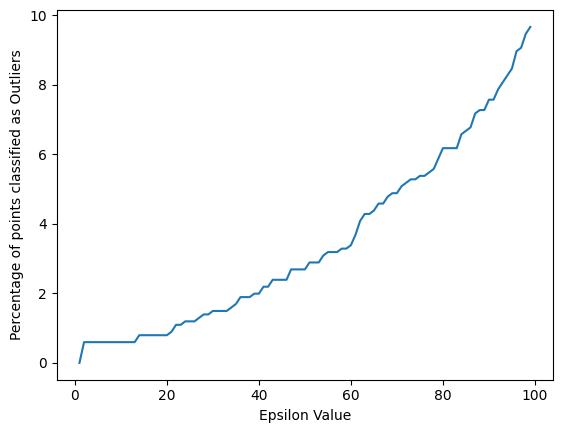

In [41]:
sns.lineplot(x=np.arange(1,100),y=outlier_percent)
plt.ylabel("Percentage of points classified as Outliers")
plt.xlabel("Epsilon Value")
#plt.xlim(0,1)
#plt.ylim(0,20)
plt.show()

# Min no of Samples = 2*num_dim

In [42]:
outlier_percent = []
number_of_outlier = []


for eps in np.linspace(0.001,10,100):

  dbscan = DBSCAN(eps = eps,min_samples=4)
  dbscan.fit(two_blobs_outliers)

  number_of_outlier.append(np.sum(dbscan.labels_==-1))

  outlier_percent.append(100*np.sum(dbscan.labels_ == -1)/len(dbscan.labels_))

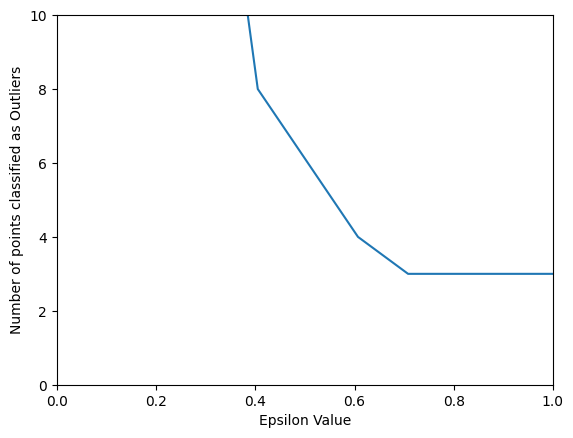

In [43]:
sns.lineplot(x=np.linspace(.001,10,100),y=number_of_outlier)
plt.ylabel("Number of points classified as Outliers")
plt.xlabel("Epsilon Value")
plt.xlim(0,1)
plt.ylim(0,10)
plt.show()

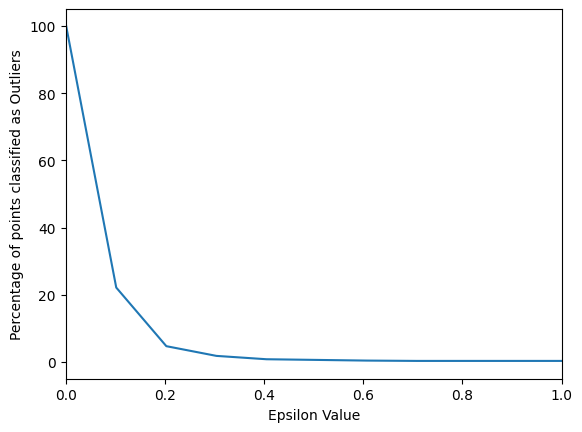

In [45]:
sns.lineplot(x=np.linspace(.001,10,100),y=outlier_percent)
plt.ylabel("Percentage of points classified as Outliers")
plt.xlabel("Epsilon Value")
plt.xlim(0,1)
#plt.ylim(0,20)
plt.show()